In [1]:
import torch
from torchcubicspline import(natural_cubic_spline_coeffs, 
                             NaturalCubicSpline)
from matplotlib import pyplot as plt

%load_ext autoreload
%autoreload 2

In [4]:
length, channels = 100, 1
t = torch.linspace(0, 1, length)
x = -1.2*(t-0.5)**2
x = x[:, None]

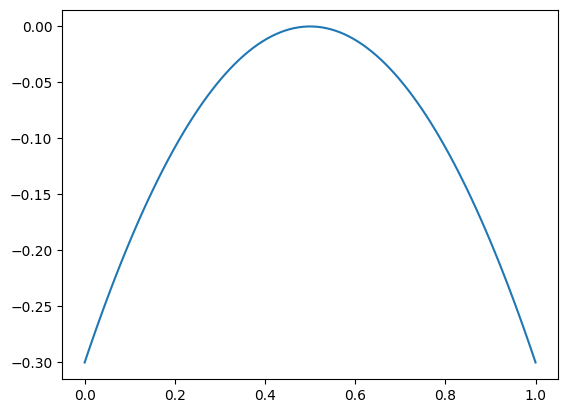

In [5]:
plt.plot(t,x)
plt.show()

In [8]:
coeffs = natural_cubic_spline_coeffs(t, x)

n = 0
print(len(coeffs))
for c in coeffs:
    n += c.size(0)
    print(c.shape)

print(f"total params: {n}")

5
torch.Size([100])
torch.Size([99, 1])
torch.Size([99, 1])
torch.Size([99, 1])
torch.Size([99, 1])
total params: 496


In [10]:
spline = NaturalCubicSpline(coeffs)

In [11]:
point = torch.tensor(0.)
out = spline.evaluate(point)
out

tensor([-0.3000])

In [12]:
xs = torch.linspace(0, 1, 100)
ys = spline.evaluate(xs)

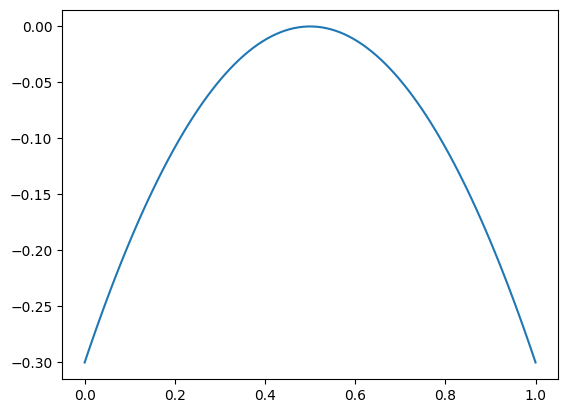

In [13]:
plt.plot(xs, ys)